## PROBLEM STATEMENT:-
The hospitality industry has undergone a significant transformation with the rise of online platforms facilitating short-term lodging and tourism. Leading this revolution is Airbnb, Inc., a pioneering American company that has reshaped travel accommodation through its innovative online marketplace. Established in 2008 in San Francisco, California, Airbnb provides a diverse range of lodging options, offering guests a unique and personalized experience. Unlike traditional hospitality providers, Airbnb operates on a commission-based model, facilitating transactions between hosts and guests without owning the properties listed on its platform.

This research analyzes the New York City Airbnb dataset to extract meaningful insights. Through rigorous data cleaning, exploratory analysis, and visualization techniques, the study aims to illuminate the dynamics of the city's lodging market. By discerning factors influencing listing availability, pricing strategies, and overall customer satisfaction, the research contributes to a deeper understanding of Airbnb’s operations in one of the world’s most dynamic urban environments. These insights hold significance for stakeholders and enthusiasts seeking to navigate the evolving landscape of short-term accommodation.


In [7]:
import pandas as pd

# Read Excel file
df = pd.read_excel("Airbnb_Open_Data.xlsx")

# Convert to CSV
df.to_csv("Airbnb_open_Data.csv", index=False)


In [4]:
# Airbnb Hotel Booking Analysis

# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Read the Airbnb Data
df = pd.read_csv('Airbnb_open_Data.csv', low_memory=False)

# Access the data
df.head()


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    102468 non-null  object 

In [13]:
print(df.columns)


Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')


In [21]:
print(df.columns.tolist())


['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price_$', 'service_fee_$', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365']


In [25]:
import pandas as pd

# ---------------------------------------------
# Clean Airbnb Hotel Booking Data
# ---------------------------------------------

# Remove dollar signs in price and service fee columns
df['price_$'] = df['price_$'].apply(lambda x: str(x).replace('$', '') if pd.notnull(x) else x)
df['service_fee_$'] = df['service_fee_$'].apply(lambda x: str(x).replace('$', '') if pd.notnull(x) else x)

# Drop missing values
df.dropna(inplace=True)

# Convert data types safely
df['price_$'] = pd.to_numeric(df['price_$'], errors='coerce')
df['service_fee_$'] = pd.to_numeric(df['service_fee_$'], errors='coerce')
df['id'] = df['id'].astype(str)
df['host id'] = df['host id'].astype(str)
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

# ✅ Convert Construction year (corrected name)
if 'Construction year' in df.columns:
    df['Construction year'] = pd.to_numeric(df['Construction year'], errors='coerce', downcast='integer')

# Correct spelling of 'brookln' to 'brooklyn'
if 'neighbourhood group' in df.columns:
    df.loc[df['neighbourhood group'] == 'brookln', 'neighbourhood group'] = 'brooklyn'

# Remove outliers in availability 365
if 'availability 365' in df.columns:
    df = df.drop(df[df['availability 365'] > 500].index)

# Check duplicates
print(df.duplicated().value_counts())

print("\n Data cleaned successfully!")


False    83389
Name: count, dtype: int64

 Data cleaned successfully!


In [53]:
Property_Types = df["room type"].value_counts().to_frame()
Property_Types 

,count
room type,
Entire home/apt,44161
Private room,37474
Shared room,1646
Hotel room,108


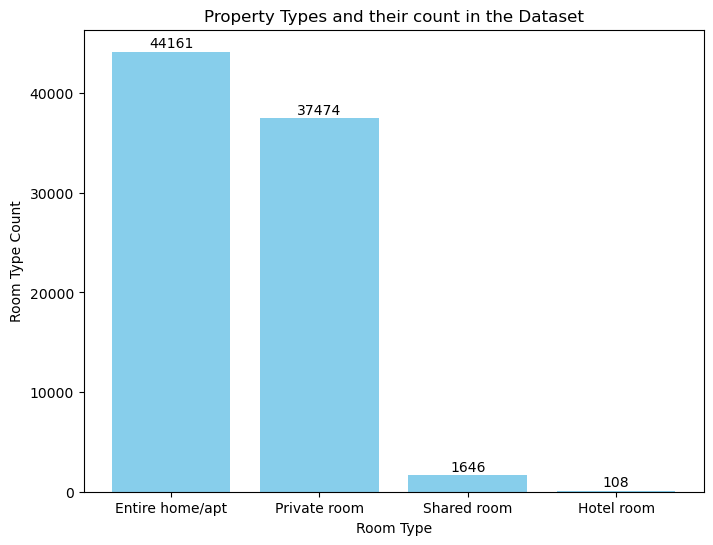

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of listings for each room type
property_types = df['room type'].value_counts().reset_index()
property_types.columns = ['room_type', 'count']

# Plot the room type count
plt.figure(figsize=(8, 6))
room_type_bar = plt.bar(property_types['room_type'], property_types['count'], color='skyblue')

# Add labels on top of each bar
for bar in room_type_bar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, int(yval), ha='center', va='bottom', fontsize=10)

# Customize the chart
plt.xlabel('Room Type')
plt.ylabel('Room Type Count')
plt.title('Property Types and their count in the Dataset')
plt.show()


C:\Users\grabi\AppData\Local\Temp\ipykernel_14236\118466372.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='neighbourhood group', y='count', data=listing_counts, palette='coolwarm')


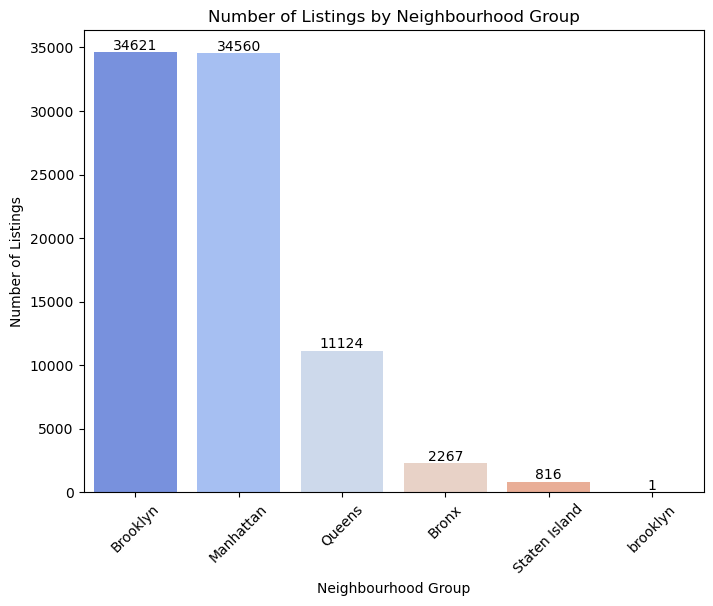

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count number of listings per neighbourhood group
listing_counts = df['neighbourhood group'].value_counts().reset_index()
listing_counts.columns = ['neighbourhood group', 'count']

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x='neighbourhood group', y='count', data=listing_counts, palette='coolwarm')

# Add labels
for index, value in enumerate(listing_counts['count']):
    plt.text(index, value + 200, str(value), ha='center', fontsize=10)

plt.title('Number of Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()


C:\Users\grabi\AppData\Local\Temp\ipykernel_14236\831497026.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='neighbourhood group', y='price_$', data=avg_price, palette='mako')


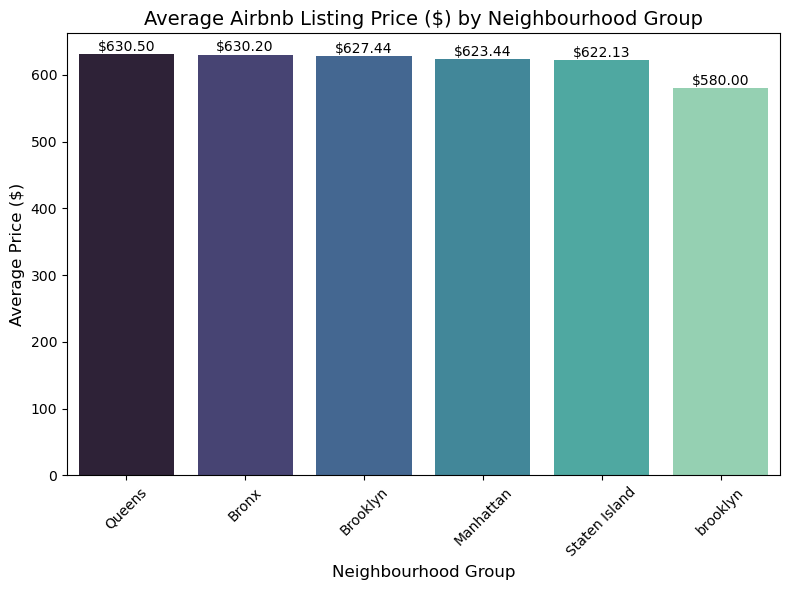

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'neighbourhood group' and calculate average price
avg_price = df.groupby('neighbourhood group')['price_$'].mean().reset_index()

# Sort from highest to lowest for clear visualization
avg_price = avg_price.sort_values(by='price_$', ascending=False)

# Visualization
plt.figure(figsize=(8, 6))
sns.barplot(x='neighbourhood group', y='price_$', data=avg_price, palette='mako')

# Add data labels
for index, value in enumerate(avg_price['price_$']):
    plt.text(index, value + 5, f"${value:.2f}", ha='center', fontsize=10)

# Titles and labels
plt.title('Average Airbnb Listing Price ($) by Neighbourhood Group', fontsize=14)
plt.xlabel('Neighbourhood Group', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Correlation matrix:
                                 Construction year   price_$  service_fee_$  \
Construction year                        1.000000 -0.003909      -0.003898   
price_$                                 -0.003909  1.000000       0.999991   
service_fee_$                           -0.003898  0.999991       1.000000   
minimum nights                           0.002457 -0.004353      -0.004326   
number of reviews                        0.003431  0.004449       0.004418   
reviews per month                        0.005311  0.004341       0.004315   
review rate number                       0.005660 -0.007421      -0.007433   
calculated host listings count          -0.002772 -0.000304      -0.000300   
availability 365                        -0.007274 -0.001207      -0.001192   

                                minimum nights  number of reviews  \
Construction year                     0.002457           0.003431   
price_$                              -0.004353           0.0

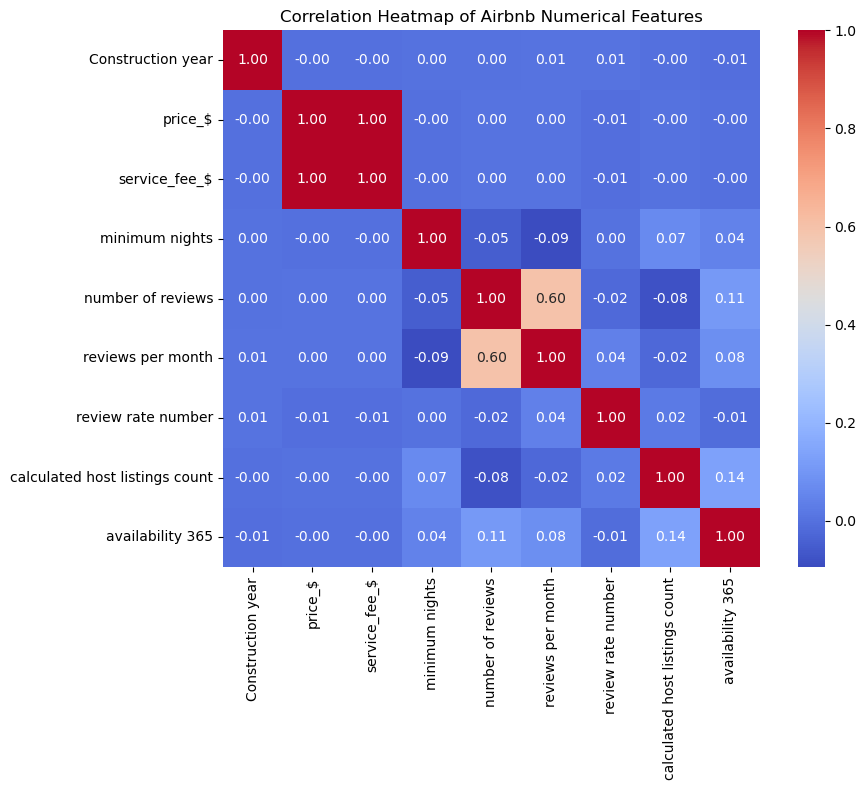

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation
numeric_cols = [
    'Construction year', 'price_$', 'service_fee_$', 'minimum nights', 
    'number of reviews', 'reviews per month', 'review rate number', 
    'calculated host listings count', 'availability 365'
]

# Make sure the columns exist in your DataFrame
numeric_cols = [c for c in numeric_cols if c in df.columns]

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Display correlation matrix
print("Correlation matrix:\n", corr_matrix)

# Heatmap visualization
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    cbar=True, 
    square=True
)
plt.title('Correlation Heatmap of Airbnb Numerical Features')
plt.tight_layout()
plt.show()
